In [9]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
CMAP_SST = cmocean.cm.balance


MONTH_LABELS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
MONTH_NAMES  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cesm2_root = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/cesm2le/'


## Downloaded and combined file locations

In [10]:
# ------------------------------------------------------------------
# Choose which file type to load: 'raw', 'yearmon', or 'mon'
# ------------------------------------------------------------------
data_kind = 'raw'

# ------------------------------------------------------------------
# Grid file location
# ------------------------------------------------------------------
grid_path = cesm2_root + 'sst/grid/cesm2le_sst_grid.nc'

# ------------------------------------------------------------------
# File locations
# ------------------------------------------------------------------
file_map = {
    'sst': {
        'raw': cesm2_root + 'sst/raw/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.SST.199001-199912.nc',
        'yearmon': cesm2_root + 'sst/yearmon/sst_cesmle_first50members_mon_199001-210012.nc',
        'mon': cesm2_root + 'sst/mon/sst_cesmle_first50members_mon_SEP_199001-210012.nc',
    },
    'aice': {
        'raw': cesm2_root + 'aice/raw/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cice.h.aice.199001-199912.nc',
        'yearmon': cesm2_root + 'aice/yearmon/aice_cesmle_first50members_mon_199001-210012.nc',
        'mon': cesm2_root + 'aice/mon/aice_cesmle_first50members_mon_SEP_199001-210012.nc',
    }
}

# Optional metrics paths left here if needed later
siextent = cesm2_root + 'aice/metrics/siextentn_first50members_SEP.nc'
siarea = cesm2_root + 'aice/metrics/siarean_first50members_SEP.nc'

## Maps of SST and AICE

In [11]:
# ------------------------------------------------------------------
# Load lat / lon from grid file
# ------------------------------------------------------------------
ds_grid = nc.Dataset(str(grid_path), 'r')
ds_grid.set_auto_mask(False)

lat = np.array(ds_grid.variables['lat'][:], dtype=np.float32)   # (nlat, nlon)
lon = np.array(ds_grid.variables['lon'][:], dtype=np.float32)  # (nlat, nlon)

ds_grid.close()

# Load AICE grid from raw file
ds_grid_aice = nc.Dataset(file_map['aice']['raw'], 'r')
ds_grid_aice.set_auto_mask(False)

lat_aice = np.array(ds_grid_aice.variables['ULAT'][:], dtype=np.float32)
lon_aice = np.array(ds_grid_aice.variables['ULON'][:], dtype=np.float32)

ds_grid_aice.close()


# ------------------------------------------------------------------
# Load SST and AICE in a loop
# ------------------------------------------------------------------
loaded = {}

for var_name in ['sst', 'aice']:
    fpath = file_map[var_name][data_kind]
    print(f'Loading {var_name.upper()} from {data_kind}: {fpath}')

    if data_kind == 'raw':
        ds = nc.Dataset(str(fpath), 'r')
        print(list(ds.variables.keys()))

        ds.set_auto_mask(False)

        if var_name == 'sst':
            # raw SST shape comment: (ntime, nlat, nlon)
            data_all = np.array(ds.variables['SST'][:], dtype=np.float32)
            data_2d = data_all[0, :, :]
        elif var_name == 'aice':
            # raw AICE shape comment: (ntime, nlat, nlon)
            data_all = np.array(ds.variables['aice'][:], dtype=np.float32)
            data_2d = data_all[0, :, :]
        ds.close()

    elif data_kind == 'yearmon':
        ds = xr.open_dataset(fpath)

        if var_name == 'sst':
            # yearmon SST shape comment: (nens, ntime, nlat, nlon)
            data_all = np.array(ds['sst'][:], dtype=np.float32)
            data_2d = data_all[0, 0, :, :]
        elif var_name == 'aice':
            # yearmon AICE shape comment: (nens, ntime, nlat, nlon)
            data_all = np.array(ds['aice'][:], dtype=np.float32)
            data_2d = data_all[0, 0, :, :]
        ds.close()

    elif data_kind == 'mon':
        ds = xr.open_dataset(fpath)

        if var_name == 'sst':
            # mon SST shape comment: (nens, ntime, nlat, nlon)
            data_all = np.array(ds['sst_mon'][:], dtype=np.float32)
            data_2d = data_all[0, 0, :, :]
        elif var_name == 'aice':
            # mon AICE shape comment: (nens, ntime, nlat, nlon)
            data_all = np.array(ds['aice_mon'][:], dtype=np.float32)
            data_2d = data_all[0, 0, :, :]
        ds.close()

    else:
        raise ValueError(f"Unsupported data_kind: {data_kind}. Choose 'raw', 'yearmon', or 'mon'.")

    loaded[var_name] = data_2d
    print(f'  {var_name.upper()} loaded: full shape {data_all.shape}, plotted shape {data_2d.shape}')

sst = loaded['sst']
aice = loaded['aice']


Loading SST from raw: /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/cesm2le/sst/raw/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.SST.199001-199912.nc
['lat', 'lon', 'gw', 'zlon', 'zlon_bnds', 'lev', 'hyam', 'hybm', 'P0', 'ilev', 'hyai', 'hybi', 'ndbase', 'nsbase', 'nbdate', 'nbsec', 'mdt', 'time', 'date', 'datesec', 'time_bnds', 'date_written', 'time_written', 'ndcur', 'nscur', 'co2vmr', 'ch4vmr', 'n2ovmr', 'f11vmr', 'f12vmr', 'sol_tsi', 'nsteph', 'SST']
  SST loaded: full shape (120, 192, 288), plotted shape (192, 288)
Loading AICE from raw: /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/cesm2le/aice/raw/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cice.h.aice.199001-199912.nc
['TLON', 'TLAT', 'ULON', 'ULAT', 'NCAT', 'VGRDi', 'VGRDs', 'VGRDb', 'tmask', 'tarea', 'uarea', 'dxt', 'dyt', 'dxu', 'dyu', 'HTN', 'HTE', 'ANGLE', 'ANGLET', 'lont_bounds', 'latt_bounds', 'lonu_bounds', 'latu_bounds', 'time', 'time_bounds', 'aice']
  AICE loaded: full shape (120, 384, 320

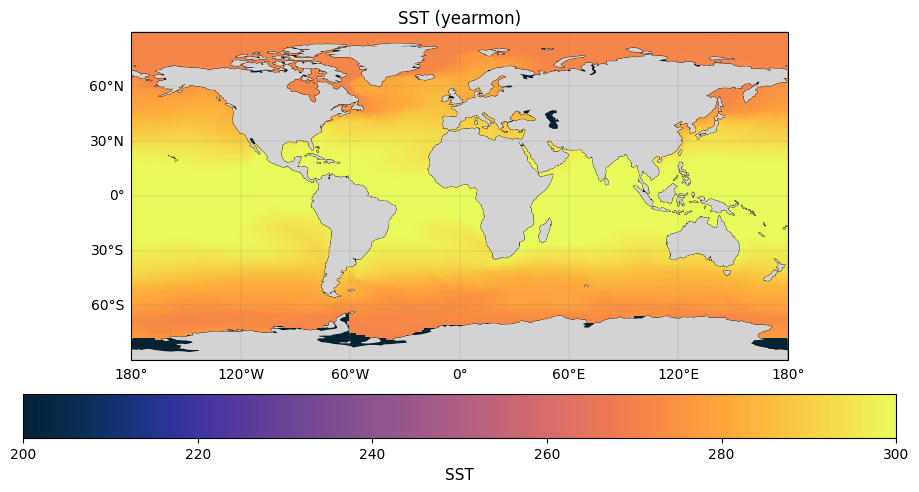

In [27]:
plt.close('all')

# ------------------------------------------------------------------
# SST figure
# ------------------------------------------------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)

im = ax.pcolormesh(
    lon,
    lat,
    sst,
    vmin = 200, vmax = 300,
    cmap=cmocean.cm.thermal,
    shading='auto',
    transform=ccrs.PlateCarree()
)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title(f'SST ({data_kind})', fontsize=12, pad=6)
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.9)
cbar.set_label('SST', fontsize=11)

plt.tight_layout()
plt.show()


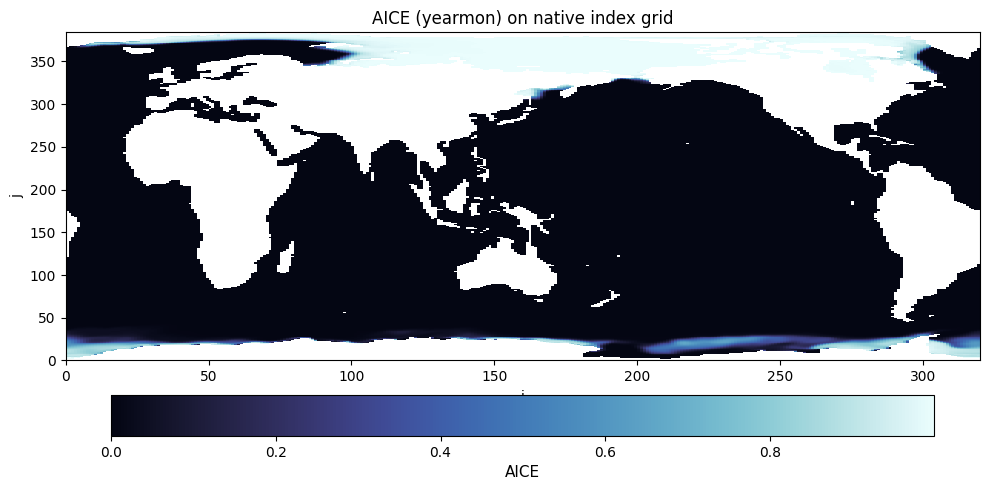

In [28]:

# ------------------------------------------------------------------
# AICE figure
# ------------------------------------------------------------------
plt.close('all')

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.pcolormesh(
    aice,
    cmap=cmocean.cm.ice,
    shading='auto'
)

ax.set_title(f'AICE ({data_kind}) on native index grid', fontsize=12, pad=6)
ax.set_xlabel('i')
ax.set_ylabel('j')

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.9)
cbar.set_label('AICE', fontsize=11)

plt.tight_layout()
plt.show()



Landmask shape : (192, 288)
Ocean fraction : 0.687
Land  fraction : 0.313


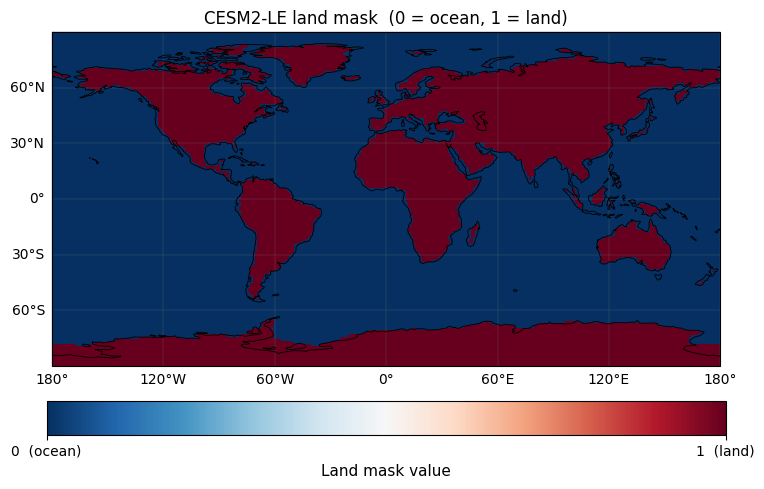

In [12]:

# ------------------------------------------------------------------
# Plot the CESM2-LE land mask on a map
# ------------------------------------------------------------------
import sys
from pathlib import Path

# Make sure project root is on the path
_project_root = Path('..').resolve()
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from configs import paths
import netCDF4 as nc

# Load landmask  (0 = ocean, 1 = land)
with nc.Dataset(paths.LANDMASK_FILE, 'r') as _ds:
    landmask = np.array(_ds.variables['landmask'][:], dtype=np.float32)

print(f'Landmask shape : {landmask.shape}')
print(f'Ocean fraction : {(landmask == 0).mean():.3f}')
print(f'Land  fraction : {(landmask == 1).mean():.3f}')

# Mask NaN so pcolormesh doesn't colour the edges oddly
landmask_plot = np.ma.masked_invalid(landmask)

plt.close('all')

fig = plt.figure(figsize=(10, 5))
ax  = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()

im = ax.pcolormesh(
    lon,                  # (nlat, nlon) — loaded from grid file above
    lat,
    landmask_plot,
    vmin=0, vmax=1,
    cmap='RdBu_r',        # blue = ocean (0), red = land (1)
    shading='auto',
    transform=ccrs.PlateCarree(),
)

ax.coastlines(linewidth=0.6, color='k', zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
gl.top_labels   = False
gl.right_labels = False

ax.set_title('CESM2-LE land mask  (0 = ocean, 1 = land)', fontsize=12, pad=6)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('Land mask value', fontsize=11)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0  (ocean)', '1  (land)'])

plt.tight_layout()
plt.show()
